In [6]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [7]:
df=pd.read_csv('data/processed/selected_features.csv')
df.shape

(112610, 31)

In [8]:
features=[
    'session_recency_min',
    'purchase_recency_min',
    'purchase_count_month_lag0',
    'purchase_count_month_ma3',
    'purchase_revenue_month_lag0',
    'session_count_month_lag0'
]
target='target_event'

In [9]:
X=df[features]
y=df[target]
print(X.shape)
print(y.shape)

(112610, 6)
(112610,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
model=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
pred_prob=model.predict_proba(X_test)[:, 1]
pred_class=model.predict(X_test)
roc_auc=roc_auc_score(
    y_test,
    pred_prob
)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8559279104714843


In [13]:
print(classification_report(y_test,pred_class))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86     15296
           1       0.69      0.70      0.70      7226

    accuracy                           0.80     22522
   macro avg       0.78      0.78      0.78     22522
weighted avg       0.81      0.80      0.81     22522



In [15]:
cm = confusion_matrix(y_test,pred_class)
print(cm)

[[13035  2261]
 [ 2133  5093]]


In [16]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance

,Feature,Importance
0,session_recency_min,0.374951
1,purchase_recency_min,0.227098
5,session_count_month_lag0,0.192863
4,purchase_revenue_month_lag0,0.079943
3,purchase_count_month_ma3,0.074253
2,purchase_count_month_lag0,0.050892


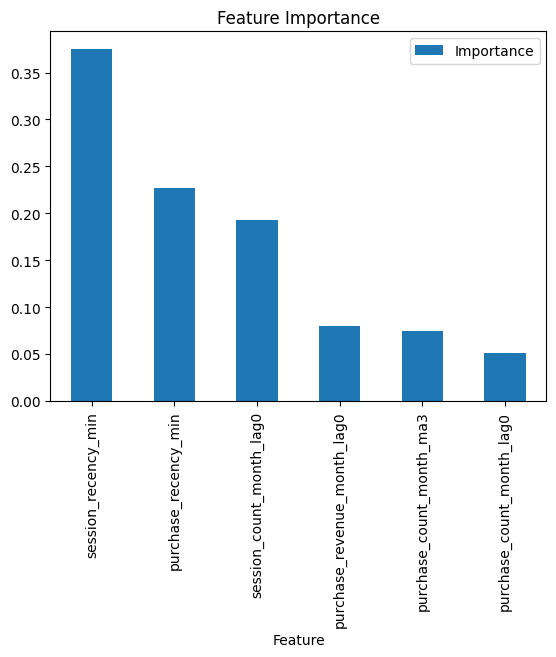

In [17]:
import matplotlib.pyplot as plt

importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)
plt.title("Feature Importance")
plt.show()

In [18]:
with open("models/churn_model_final.pkl","wb") as file:
    pickle.dump(
        model,
        file
    )
print("Model Saved Successfully")

Model Saved Successfully


In [20]:
good_customer = pd.DataFrame({
    'session_recency_min':[2],
    'purchase_recency_min':[3],
    'purchase_count_month_lag0':[10],
    'purchase_count_month_ma3':[8],
    'purchase_revenue_month_lag0':[500],
    'session_count_month_lag0':[8]

})
print(model.predict_proba(good_customer))

[[0.72591448 0.27408552]]


In [21]:
bad_customer = pd.DataFrame({
    'session_recency_min':[80],
    'purchase_recency_min':[70],
    'purchase_count_month_lag0':[0],
    'purchase_count_month_ma3':[0],
    'purchase_revenue_month_lag0':[0],
    'session_count_month_lag0':[0]
})
print(model.predict_proba(bad_customer))

[[0.0141273 0.9858727]]
